# Project 1: Salary Prediction Using Machine Learning

## Project Category
Regression

## Objective
The aim of this project is to predict salary based on input features such as years of experience or other related variables.

## Models Used
- Linear Regression
- Random Forest Regressor

## Evaluation Metrics
- Mean Absolute Error
- Mean Squared Error
- R2 Score

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

In [ ]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)

df["Price"] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
print(df.shape)

df.info()

df.describe()

(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
# Dataset Overview
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset shape: (20640, 9)

Columns:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

Data Types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
Price         float64
dtype: object

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

Duplicate Rows:
0


In [ ]:
# Statistical Summary
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


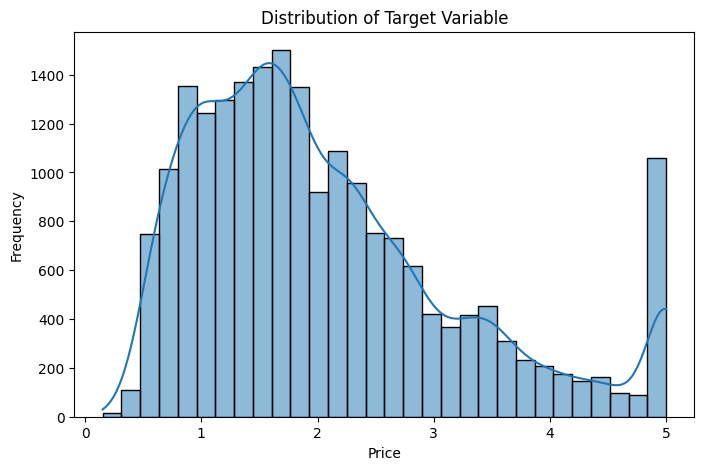

In [ ]:
# Target Variable Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distribution of Target Variable")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import seaborn as sns

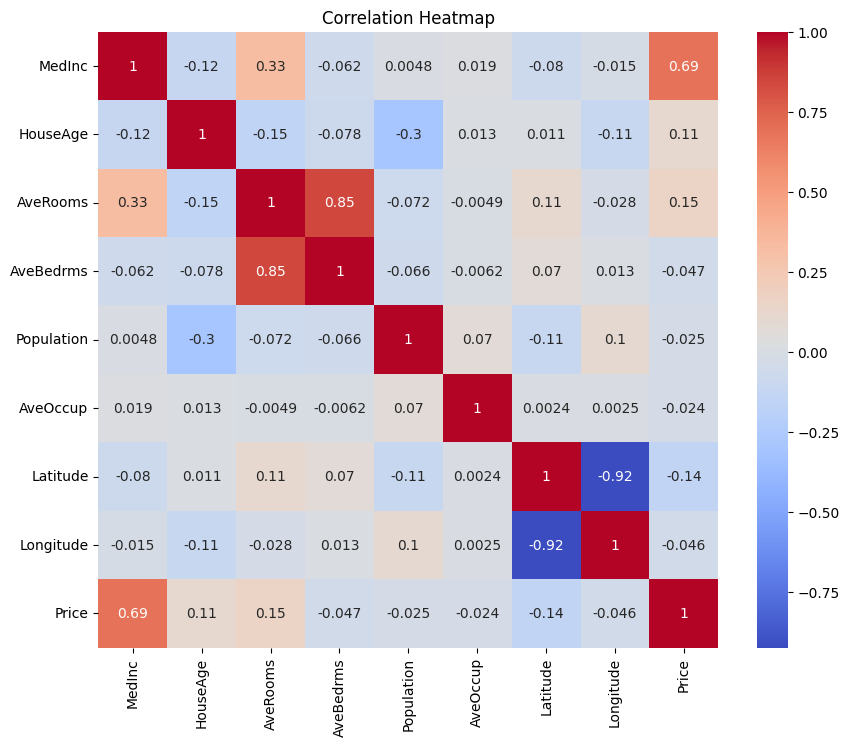

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression Results
MAE: 0.5332001304956553
RMSE: 0.7455813830127764
R2 Score: 0.5757877060324508


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results
MAE: 0.32754256845930246
RMSE: 0.5053399773665033
R2 Score: 0.8051230593157366


In [ ]:
import pickle

with open("regression_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

In [ ]:
# Model Comparison Table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)]})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.533200,0.745581,0.575788
1,Random Forest Regressor,0.327543,0.505340,0.805123


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False)

feature_importance

,Feature,Importance
0,MedInc,0.524871
5,AveOccup,0.138443
6,Latitude,0.088936
7,Longitude,0.088629
1,HouseAge,0.054593
2,AveRooms,0.044272
4,Population,0.030650
3,AveBedrms,0.029606


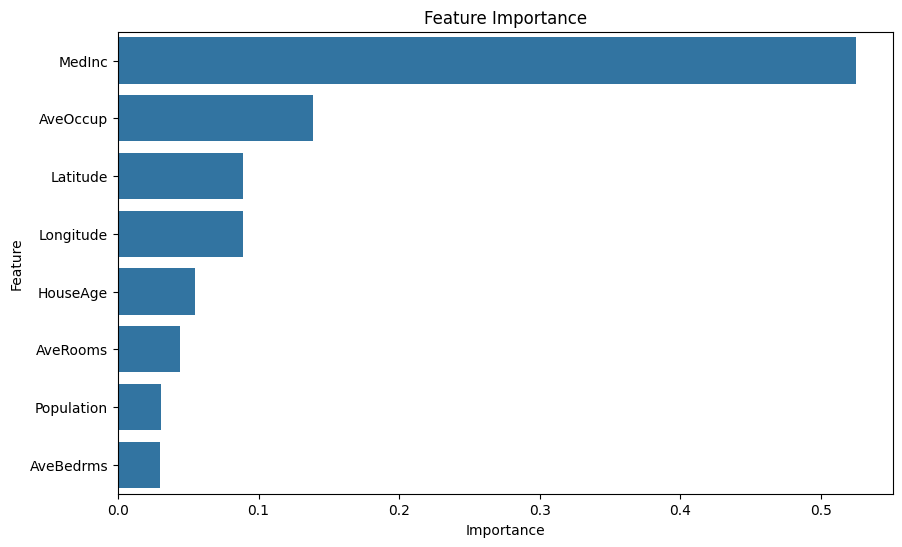

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance)

plt.title("Feature Importance")

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Linear Regression Model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# Model oluşturma
lr_model = LinearRegression()

# Model eğitme
lr_model.fit(X_train, y_train)

# Tahmin yapma
lr_pred = lr_model.predict(X_test)

# Sonuçlar
print("Linear Regression Results")

print("MAE:", mean_absolute_error(y_test, lr_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression Results
MAE: 0.5332001304956553
RMSE: 0.7455813830127764
R2 Score: 0.5757877060324508


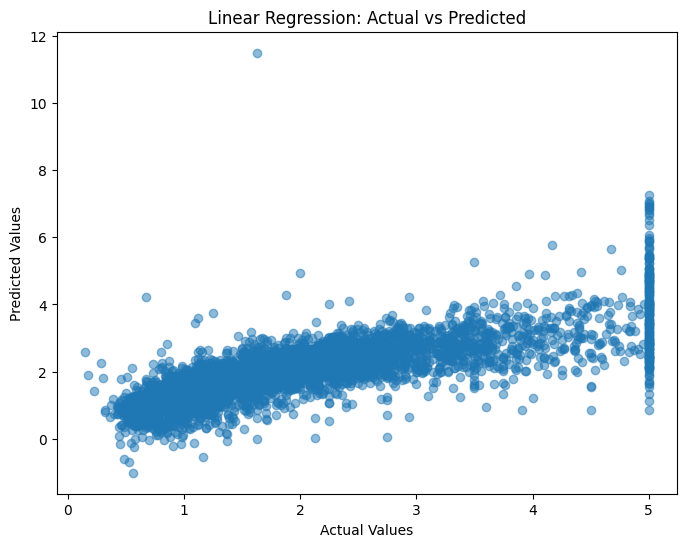

In [ ]:
# Actual vs Predicted Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Linear Regression: Actual vs Predicted")

plt.show()

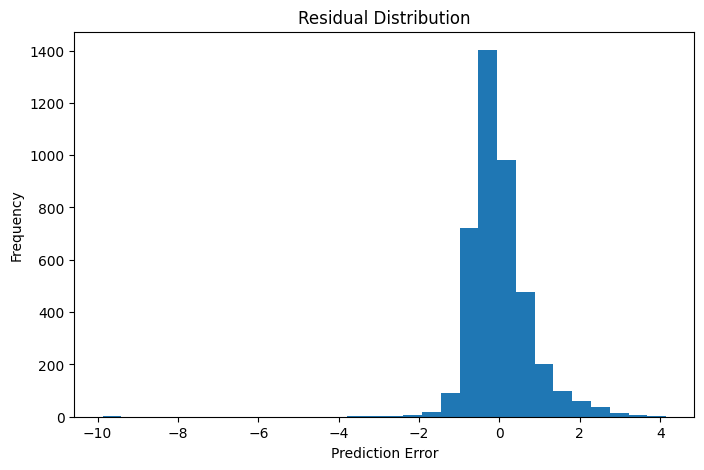

In [ ]:
# Residual Analysis

residuals = y_test - lr_pred

plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

## Linear Regression Results

The Linear Regression model achieved an R2 score of approximately 0.57.

This result indicates that the model was able to explain around 57% of the variance in the target variable. However, compared to Random Forest Regressor, the performance remained lower due to the nonlinear structure of the dataset.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print(r2_score(y_test, gb_pred))

0.7756446042829697


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Results")

print("MAE:", mean_absolute_error(y_test, dt_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))

print("R2 Score:", r2_score(y_test, dt_pred))

Decision Tree Results
MAE: 0.45467918846899225
RMSE: 0.7037294974840077
R2 Score: 0.622075845135081


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Results")

print("MAE:", mean_absolute_error(y_test, gb_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))

print("R2 Score:", r2_score(y_test, gb_pred))

Gradient Boosting Results
MAE: 0.3716425690425596
RMSE: 0.5422152016168362
R2 Score: 0.7756446042829697


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Results")

print("MAE:", mean_absolute_error(y_test, xgb_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

print("R2 Score:", r2_score(y_test, xgb_pred))

XGBoost Results
MAE: 0.31712792950532226
RMSE: 0.47872208016296186
R2 Score: 0.8251119811898733


In [ ]:
results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"],

    "R2 Score": [

        r2_score(y_test, lr_pred),

        r2_score(y_test, dt_pred),

        r2_score(y_test, rf_pred),

        r2_score(y_test, gb_pred),

        r2_score(y_test, xgb_pred)]})

results

,Model,R2 Score
0,Linear Regression,0.575788
1,Decision Tree,0.622076
2,Random Forest,0.805123
3,Gradient Boosting,0.775645
4,XGBoost,0.825112


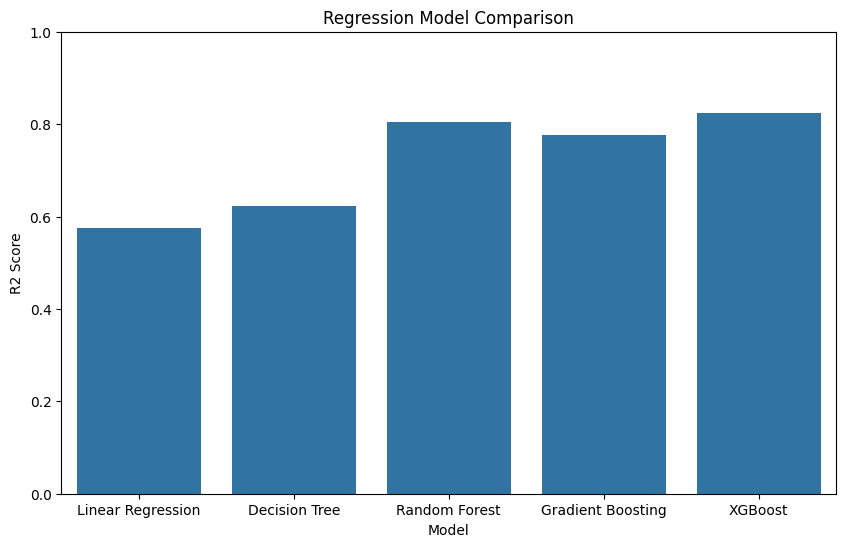

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=results)

plt.title("Regression Model Comparison")

plt.ylim(0,1)

plt.show()